# 🔬 Sort Complexity Lab

A data-science style notebook that compares **Bubble Sort**, **Insertion Sort**, **Selection Sort**, **Merge Sort**, and **Quick Sort** — measuring real performance and visualizing how they scale.

---

## 📚 What is Time Complexity?

**Time complexity** describes how the number of operations an algorithm performs grows as the input size `n` increases. We express this using **Big-O notation**:

| Notation | Name | Example |
|---|---|---|
| O(1) | Constant | Array index lookup |
| O(n) | Linear | Single loop |
| O(n log n) | Linearithmic | Merge Sort, Quick Sort |
| O(n²) | Quadratic | Bubble Sort, Insertion Sort |

> **Key insight:** For large `n`, an O(n log n) algorithm is dramatically faster than an O(n²) one.

## 1. Setup — Imports & Configuration

In [1]:
from __future__ import annotations

import math
import random
import time
from dataclasses import dataclass
from time import perf_counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Nice plot style
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#eee',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': '#1e1e3a',
    'legend.edgecolor': '#555',
    'font.family':      'monospace',
})

ALGO_COLORS = {
    'Bubble Sort':    '#ff6b6b',
    'Insertion Sort': '#ffa94d',
    'Selection Sort': '#ffd43b',
    'Merge Sort':     '#69db7c',
    'Quick Sort':     '#74c0fc',
}

print('✅ Setup complete.')

Matplotlib is building the font cache; this may take a moment.


✅ Setup complete.


## 2. Algorithm Implementations

Each algorithm is instrumented to count **comparisons**, **array writes/moves**, and **wall-clock time**.

In [2]:
@dataclass
class SortResult:
    name: str
    sorted_values: list
    comparisons: int
    swaps: int
    elapsed_ms: float

    def __repr__(self):
        return (
            f"{self.name}: comparisons={self.comparisons:,}, "
            f"writes={self.swaps:,}, time={self.elapsed_ms:.4f}ms"
        )


# ── Bubble Sort ───────────────────────────────────────────────────────────────
def bubble_sort(values: list) -> SortResult:
    arr = values.copy()
    n = len(arr)
    comparisons = swaps = 0
    start = perf_counter()
    for i in range(n):
        swapped = False
        for j in range(0, n - i - 1):
            comparisons += 1
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swaps += 1
                swapped = True
        if not swapped:
            break
    return SortResult('Bubble Sort', arr, comparisons, swaps, (perf_counter() - start) * 1000)


# ── Insertion Sort ────────────────────────────────────────────────────────────
def insertion_sort(values: list) -> SortResult:
    arr = values.copy()
    n = len(arr)
    comparisons = swaps = 0
    start = perf_counter()
    for i in range(1, n):
        key = arr[i]
        j = i - 1
        while j >= 0:
            comparisons += 1
            if arr[j] > key:
                arr[j + 1] = arr[j]
                swaps += 1
                j -= 1
            else:
                break
        arr[j + 1] = key
    return SortResult('Insertion Sort', arr, comparisons, swaps, (perf_counter() - start) * 1000)


# ── Selection Sort ────────────────────────────────────────────────────────────
def selection_sort(values: list) -> SortResult:
    arr = values.copy()
    n = len(arr)
    comparisons = swaps = 0
    start = perf_counter()
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            comparisons += 1
            if arr[j] < arr[min_idx]:
                min_idx = j
        if min_idx != i:
            arr[i], arr[min_idx] = arr[min_idx], arr[i]
            swaps += 1
    return SortResult('Selection Sort', arr, comparisons, swaps, (perf_counter() - start) * 1000)


# ── Merge Sort ────────────────────────────────────────────────────────────────
def merge_sort(values: list) -> SortResult:
    arr = values.copy()
    comparisons = swaps = 0
    start = perf_counter()
    def merge(left, right):
        nonlocal comparisons, swaps
        merged, i, j = [], 0, 0
        while i < len(left) and j < len(right):
            comparisons += 1
            if left[i] <= right[j]:
                merged.append(left[i]); i += 1
            else:
                merged.append(right[j]); j += 1
        merged.extend(left[i:]); merged.extend(right[j:])
        swaps += len(left) + len(right)
        return merged
    def sort(chunk):
        if len(chunk) <= 1: return chunk
        mid = len(chunk) // 2
        return merge(sort(chunk[:mid]), sort(chunk[mid:]))
    sorted_arr = sort(arr)
    return SortResult('Merge Sort', sorted_arr, comparisons, swaps, (perf_counter() - start) * 1000)


# ── Quick Sort ────────────────────────────────────────────────────────────────
def quick_sort(values: list) -> SortResult:
    arr = values.copy()
    comparisons = swaps = 0
    start = perf_counter()
    def partition(a, low, high):
        nonlocal comparisons, swaps
        pivot = a[high]; i = low - 1
        for j in range(low, high):
            comparisons += 1
            if a[j] <= pivot:
                i += 1; a[i], a[j] = a[j], a[i]; swaps += 1
        a[i+1], a[high] = a[high], a[i+1]; swaps += 1
        return i + 1
    def sort(a, low, high):
        if low < high:
            pi = partition(a, low, high)
            sort(a, low, pi - 1); sort(a, pi + 1, high)
    sort(arr, 0, len(arr) - 1)
    return SortResult('Quick Sort', arr, comparisons, swaps, (perf_counter() - start) * 1000)


ALL_ALGORITHMS = [bubble_sort, insertion_sort, selection_sort, merge_sort, quick_sort]
print('✅ All 5 sorting algorithms defined.')

✅ All 5 sorting algorithms defined.


## 3. 📐 Theoretical Complexity Reference Table

In [3]:
theory = {
    'Algorithm':     ['Bubble Sort', 'Insertion Sort', 'Selection Sort', 'Merge Sort', 'Quick Sort'],
    'Best Case':     ['O(n)',        'O(n)',            'O(n²)',          'O(n log n)', 'O(n log n)'],
    'Average Case':  ['O(n²)',       'O(n²)',           'O(n²)',          'O(n log n)', 'O(n log n)'],
    'Worst Case':    ['O(n²)',       'O(n²)',           'O(n²)',          'O(n log n)', 'O(n²)'     ],
    'Space':         ['O(1)',        'O(1)',            'O(1)',           'O(n)',        'O(log n)'  ],
    'Stable':        ['✅ Yes',      '✅ Yes',          '❌ No',          '✅ Yes',      '❌ No'     ],
}

df_theory = pd.DataFrame(theory).set_index('Algorithm')
df_theory.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#16213e'), ('color', '#e0e0e0'), ('font-size', '13px')]},
    {'selector': 'td', 'props': [('background-color', '#1a1a2e'), ('color', '#ccc'), ('font-size', '12px')]},
])

,Best Case,Average Case,Worst Case,Space,Stable
Algorithm,,,,,
Bubble Sort,O(n),O(n²),O(n²),O(1),✅ Yes
Insertion Sort,O(n),O(n²),O(n²),O(1),✅ Yes
Selection Sort,O(n²),O(n²),O(n²),O(1),❌ No
Merge Sort,O(n log n),O(n log n),O(n log n),O(n),✅ Yes
Quick Sort,O(n log n),O(n log n),O(n²),O(log n),❌ No


## 4. 🔢 Define Your Input

Edit the cell below to use your own list, a preset, or generate random numbers.

In [4]:
# ── Choose your input ──────────────────────────────────────────────────────
# Option A: Custom list
# my_input = [64, 34, 25, 12, 22, 11, 90]

# Option B: Random (change count & range as you like)
COUNT = 20          # how many numbers
MIN_VAL, MAX_VAL = 1, 500
random.seed(42)     # remove or change seed for different results each run
my_input = random.sample(range(MIN_VAL, MAX_VAL + 1), COUNT)

# Option C: Presets
# my_input = list(range(1, 21))           # already sorted
# my_input = list(range(20, 0, -1))       # reverse sorted

print(f'Input (n={len(my_input)}): {my_input}')

Input (n=20): [328, 58, 13, 380, 141, 126, 115, 72, 378, 53, 347, 457, 280, 45, 303, 217, 17, 16, 48, 112]


## 5. 📊 Run All Algorithms & Compare

In [5]:
results = [fn(my_input) for fn in ALL_ALGORITHMS]

df = pd.DataFrame([
    {
        'Algorithm':       r.name,
        'Comparisons':     r.comparisons,
        'Array Writes':    r.swaps,
        'Time (ms)':       round(r.elapsed_ms, 5),
    }
    for r in results
]).set_index('Algorithm')

print(f'\n📋 Results for n = {len(my_input)}:\n')
df


📋 Results for n = 20:



,Comparisons,Array Writes,Time (ms)
Algorithm,,,
Bubble Sort,187,113,0.01400
Insertion Sort,130,113,0.00821
Selection Sort,190,17,0.00758
Merge Sort,63,88,0.01754
Quick Sort,62,45,0.00837


## 6. 📊 Bar Charts — Comparisons & Time

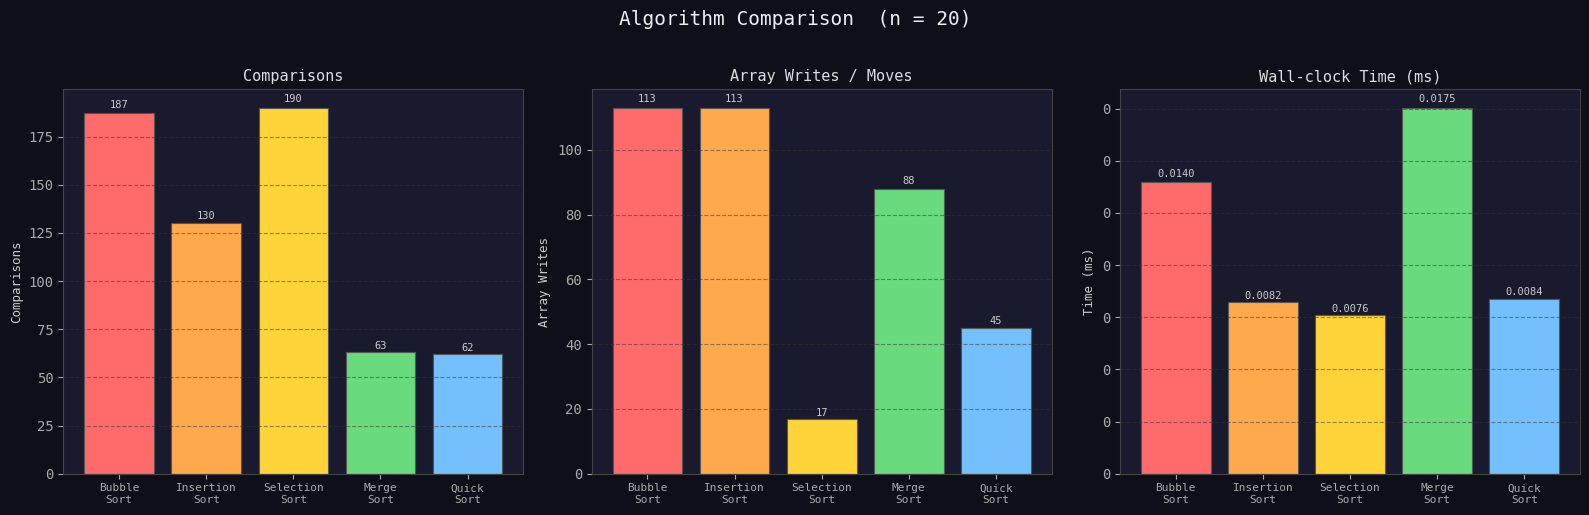

In [6]:
names  = [r.name for r in results]
colors = [ALGO_COLORS[n] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Algorithm Comparison  (n = {len(my_input)})', fontsize=14, color='#eee', y=1.02)

metrics = [
    ([r.comparisons for r in results], 'Comparisons',   'Comparisons'),
    ([r.swaps       for r in results], 'Array Writes',  'Array Writes / Moves'),
    ([r.elapsed_ms  for r in results], 'Time (ms)',     'Wall-clock Time (ms)'),
]

for ax, (vals, ylabel, title) in zip(axes, metrics):
    bars = ax.bar(names, vals, color=colors, edgecolor='#555', linewidth=0.8)
    ax.set_title(title, fontsize=11, color='#ddd')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace(' Sort', '\nSort') for n in names], fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(axis='y')
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{val:,.4f}' if isinstance(val, float) else f'{val:,}',
            ha='center', va='bottom', fontsize=7.5, color='#ccc'
        )

plt.tight_layout()
plt.show()

## 7. 🏆 Leaderboard

In [7]:
medals = ['🥇', '🥈', '🥉', '4️⃣', '5️⃣']

print('━' * 55)
print(f'  🏆  LEADERBOARD  —  n = {len(my_input)}')
print('━' * 55)

for category, key, fmt in [
    ('Fewest Comparisons', 'comparisons', lambda x: f'{x:,}'),
    ('Fewest Array Writes', 'swaps',      lambda x: f'{x:,}'),
    ('Fastest (time)',      'elapsed_ms', lambda x: f'{x:.5f} ms'),
]:
    ranked = sorted(results, key=lambda r: getattr(r, key))
    print(f'\n  📌 {category}')
    for i, r in enumerate(ranked):
        print(f'    {medals[i]}  {r.name:<16}  {fmt(getattr(r, key))}')

print('━' * 55)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🏆  LEADERBOARD  —  n = 20
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  📌 Fewest Comparisons
    🥇  Quick Sort        62
    🥈  Merge Sort        63
    🥉  Insertion Sort    130
    4️⃣  Bubble Sort       187
    5️⃣  Selection Sort    190

  📌 Fewest Array Writes
    🥇  Selection Sort    17
    🥈  Quick Sort        45
    🥉  Merge Sort        88
    4️⃣  Bubble Sort       113
    5️⃣  Insertion Sort    113

  📌 Fastest (time)
    🥇  Selection Sort    0.00758 ms
    🥈  Insertion Sort    0.00821 ms
    🥉  Quick Sort        0.00837 ms
    4️⃣  Bubble Sort       0.01400 ms
    5️⃣  Merge Sort        0.01754 ms
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 8. ⏱️ Speed Benchmark — Real Timing Across Input Sizes

In [8]:
BENCH_SIZES   = [10, 50, 100, 250, 500, 750, 1000]
REPEATS       = 3     # average over this many runs per size
SLOW_CUTOFF   = 500   # skip O(n²) algos beyond this size (set to 9999 to disable)

SLOW_ALGOS = {'Bubble Sort', 'Insertion Sort', 'Selection Sort'}

bench_data: dict[str, list] = {fn.__name__.replace('_', ' ').title(): [] for fn in ALL_ALGORITHMS}
bench_data['n'] = BENCH_SIZES

# fix key names to match result.name
bench_timings: dict[str, dict[int, float]] = {r.name: {} for r in results}

for size in BENCH_SIZES:
    for fn in ALL_ALGORITHMS:
        algo_name = fn(list(range(size))).name   # cheap call just to get name
        if algo_name in SLOW_ALGOS and size > SLOW_CUTOFF:
            bench_timings[algo_name][size] = None
            continue
        times = []
        for _ in range(REPEATS):
            data = random.sample(range(1, size * 10 + 1), size)
            r = fn(data)
            times.append(r.elapsed_ms)
        bench_timings[algo_name][size] = round(sum(times) / len(times), 5)

print('✅ Benchmark complete!')

✅ Benchmark complete!


/var/folders/77/54klpm351_51nhjlwj4_b6y00000gn/T/ipykernel_29771/1938978628.py:18: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/77/54klpm351_51nhjlwj4_b6y00000gn/T/ipykernel_29771/1938978628.py:18: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/laliteja/Desktop/sort-complexity/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/laliteja/Desktop/sort-complexity/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


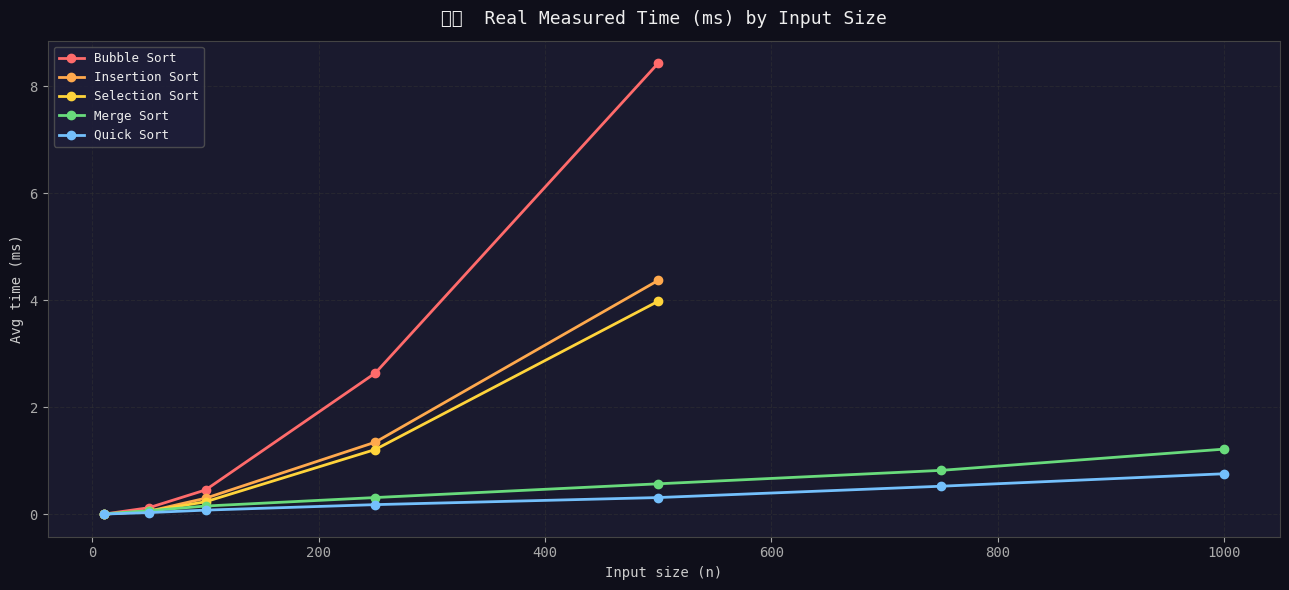

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_title('⏱️  Real Measured Time (ms) by Input Size', fontsize=13, color='#eee', pad=12)

for algo_name, color in ALGO_COLORS.items():
    xs, ys = [], []
    for size in BENCH_SIZES:
        val = bench_timings[algo_name].get(size)
        if val is not None:
            xs.append(size)
            ys.append(val)
    if xs:
        ax.plot(xs, ys, marker='o', linewidth=2, color=color, label=algo_name, markersize=6)

ax.set_xlabel('Input size (n)', fontsize=10)
ax.set_ylabel('Avg time (ms)', fontsize=10)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

## 9. 📈 Theoretical Growth Curves — Big-O Visualization

/var/folders/77/54klpm351_51nhjlwj4_b6y00000gn/T/ipykernel_29771/620970507.py:22: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/laliteja/Desktop/sort-complexity/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


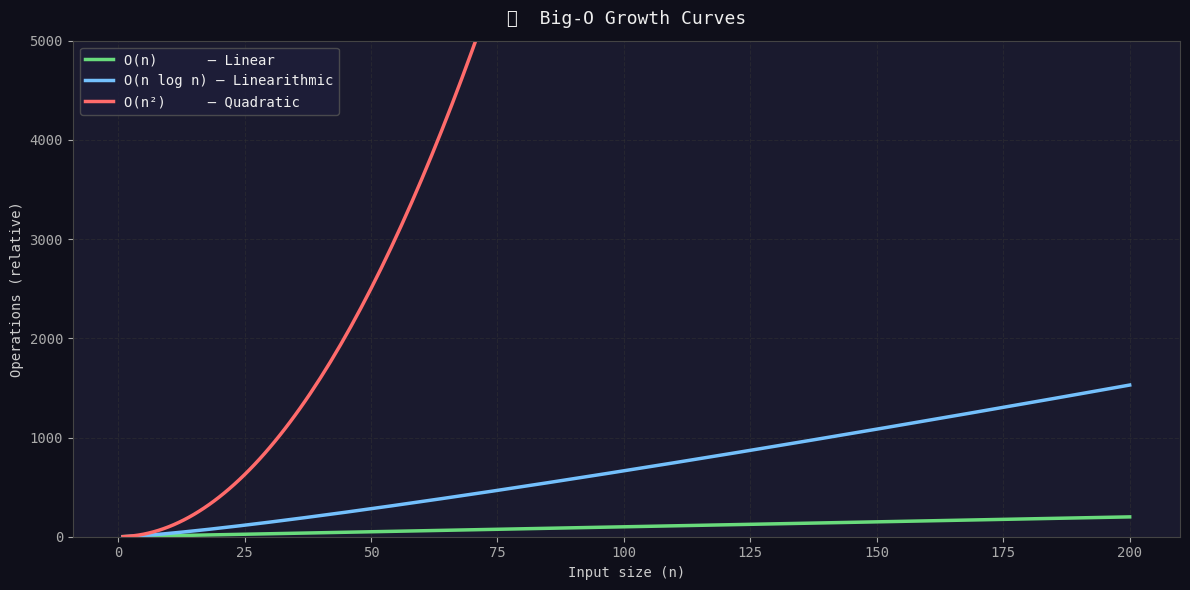

In [10]:
ns = range(1, 201)

curves = {
    'O(n)      — Linear':        [n              for n in ns],
    'O(n log n) — Linearithmic': [n * math.log2(n) if n > 1 else 0 for n in ns],
    'O(n²)     — Quadratic':     [n * n          for n in ns],
}

curve_colors = ['#69db7c', '#74c0fc', '#ff6b6b']

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title('📈  Big-O Growth Curves', fontsize=13, color='#eee', pad=12)

for (label, vals), color in zip(curves.items(), curve_colors):
    ax.plot(list(ns), vals, linewidth=2.5, color=color, label=label)

ax.set_xlabel('Input size (n)', fontsize=10)
ax.set_ylabel('Operations (relative)', fontsize=10)
ax.set_ylim(0, 5000)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.show()

## 10. 📤 Export Results to CSV

In [11]:
export_path = 'sort_results.csv'
df.reset_index().to_csv(export_path, index=False)
print(f'✅ Results exported to {export_path}')
df

✅ Results exported to sort_results.csv


,Comparisons,Array Writes,Time (ms)
Algorithm,,,
Bubble Sort,187,113,0.01400
Insertion Sort,130,113,0.00821
Selection Sort,190,17,0.00758
Merge Sort,63,88,0.01754
Quick Sort,62,45,0.00837
